# List of ML Model Experiments with different conditions 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from torch.utils.data import DataLoader
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [ ]:
class CNNHistogramNormalization(nn.Module):
    def __init__(self):
        super(CNNHistogramNormalization, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(32, 128, kernel_size = 5, padding =2)
        self.relu = nn.ReLU()
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 2)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = torch.nn.functional.normalize(x, p=2, dim=-1)
        x = self.global_avg_pool(x)
        x = x.view(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.softmax(x)
        return x

input_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/5th_int_masked"

label_map = {"GMjo": 0, "Ujo": 1}

song_data = {}

for song_folder in os.listdir(input_dir):
    song_path = os.path.join(input_dir, song_folder)
    if not os.path.isdir(song_path):
        continue

    X_list = []
    y_list = []

    for file in os.listdir(song_path):
        if file.endswith(".npy"):
            file_path = os.path.join(song_path, file)
            X_sample = np.load(file_path)

            if "GMjo" in file:
                y_label = label_map["GMjo"]
            elif "Ujo" in file:
                y_label = label_map["Ujo"]
            else:
                continue

            X_list.append(X_sample)
            y_list.append(y_label)

    if X_list:
        song_data[song_folder] = (torch.tensor(X_list, dtype=torch.float32).unsqueeze(1),
                                  torch.tensor(y_list, dtype=torch.long))

song_names = list(song_data.keys())
num_songs = len(song_names)

loo_losses = []
loo_accuracies = []

for i in range(num_songs):
    test_song = song_names[i]
    print(f"\n LOO Cross Validation - {test_song}")
    val_X, val_y = song_data[test_song]

    train_X = []
    train_y = []
    for j, song in enumerate(song_names):
        if i != j:
            train_X.append(song_data[song][0])
            train_y.append(song_data[song][1])

    train_X = torch.cat(train_X, dim=0)
    train_y = torch.cat(train_y, dim=0)

    model = CNNHistogramNormalization()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    criterion = nn.CrossEntropyLoss()

    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(train_X)
        loss = criterion(outputs, train_y)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        val_output = model(val_X)
        #print("\n Validation Output:\n", val_output.numpy())
        val_loss = criterion(val_output, val_y)
        pred = torch.argmax(val_output, dim=1)
        accuracy = (pred == val_y).float().mean().item()
    loo_losses.append(val_loss.item())
    loo_accuracies.append(accuracy)

    print(f"Validation Loss: {val_loss.item():.4f}, Accuracy: {accuracy:.4f}")
    print(f"Prediction: {pred.numpy()}")
    print(f"Answer: {val_y.numpy()}")

print("\n  LOO-CV Result  🔹")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accuracies):.4f}")


 LOO Cross Validation - 적벽가_군사설움타령_계면조
Validation Loss: 0.5058, Accuracy: 1.0000
Prediction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Answer: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

 LOO Cross Validation - 수궁가_소지노화_우조
Validation Loss: 1.0897, Accuracy: 0.0000
Prediction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Answer: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

 LOO Cross Validation - 박봉술_춘향가_천자뒤풀이_우조
Validation Loss: 1.1664, Accuracy: 0.0000
Prediction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Answer: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

 LOO Cross Validation - 김창환_춘향가_이별가_계면조
Validation Loss: 0.5010, Accuracy: 1.0000
Prediction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Answer: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

 LOO Cross Validation - 조학진_수궁풍류_계면조
Validation Loss: 0.4891, Accuracy: 1.0000
Prediction: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Answer: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

 LOO Cross Validation - 박봉술_춘향가_방자설경_우조
Validation Loss: 1.0709, Ac

# Random Forest Classifier


====== LOO Cross-Validation Results ======
      Test Song  Accuracy                                                                                                   Prediction                                                                                                 Ground Truth
    수궁가_소지노화_우조  0.111111                                                                                  [0, 1, 0, 0, 0, 0, 0, 0, 0]                                                                                  [1, 1, 1, 1, 1, 1, 1, 1, 1]
  박봉술_춘향가_천자뒤풀이  0.066667                                                                [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]                                                                [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
김창환_춘향가_이별가_계면조  0.800000                                                                               [0, 0, 0, 0, 1, 1, 0, 0, 0, 0]                                                                               [0, 0, 0, 0

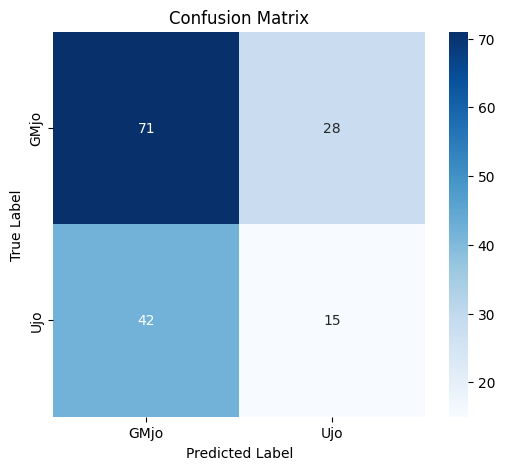

In [4]:
input_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/5th_int_masked_20"

label_map = {"GMjo": 0, "Ujo": 1}

song_data = {}

for song_folder in os.listdir(input_dir):
    song_path = os.path.join(input_dir, song_folder)
    if not os.path.isdir(song_path):
        continue

    X_list = []
    y_list = []

    for file in os.listdir(song_path):
        if file.endswith(".npy"):
            file_path = os.path.join(song_path, file)
            X_sample = np.load(file_path)

            if "GMjo" in file:
                y_label = label_map["GMjo"]
            elif "Ujo" in file:
                y_label = label_map["Ujo"]
            else:
                continue

            X_list.append(X_sample.flatten())
            y_list.append(y_label)

    if X_list:
        song_data[song_folder] = (np.array(X_list), np.array(y_list))

song_names = list(song_data.keys())
num_songs = len(song_names)

loo_accuracies = []
y_true, y_pred = [], []
evaluation_results = []

for i in range(num_songs):
    test_song = song_names[i]
    val_X, val_y = song_data[test_song]

    train_X, train_y = [], []
    for j, song in enumerate(song_names):
        if i != j:
            train_X.append(song_data[song][0])
            train_y.append(song_data[song][1])

    train_X = np.vstack(train_X)
    train_y = np.concatenate(train_y)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(train_X, train_y)

    val_pred = model.predict(val_X)
    y_true.extend(val_y)
    y_pred.extend(val_pred)

    accuracy = accuracy_score(val_y, val_pred)
    loo_accuracies.append(accuracy)

    evaluation_results.append([test_song, accuracy, val_pred.tolist(), val_y.tolist()])

eval_df = pd.DataFrame(evaluation_results, columns=["Test Song", "Accuracy", "Prediction", "Ground Truth"])

print("\n====== LOO Cross-Validation Results ======")
print(eval_df.to_string(index=False))

print("\n====== Overall Evaluation ======")
print(f"Average Validation Accuracy: {np.mean(loo_accuracies):.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["GMjo", "Ujo"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["GMjo", "Ujo"], yticklabels=["GMjo", "Ujo"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


====== LOO-CV Evaluation Results ======
       Test Song  Accuracy                                                                                                                                                                                       Prediction                                                                                                                                                                                     Ground Truth
  적벽가_군사설움타령_계면조  0.789474                                                                                                                                        [0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
     수궁가_소지노화_우조  0.368421                                                                                                           

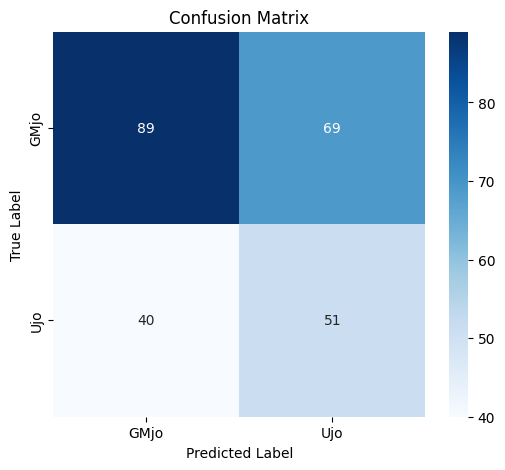

In [ ]:
input_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/5th_int"

label_map = {"GMjo": 0, "Ujo": 1}

song_data = {}

if os.path.exists(input_dir) and os.listdir(input_dir):
    for song_folder in os.listdir(input_dir):
        song_path = os.path.join(input_dir, song_folder)
        if not os.path.isdir(song_path):
            continue

        X_list = []
        y_list = []

        for file in os.listdir(song_path):
            if file.endswith(".npy"):
                file_path = os.path.join(song_path, file)
                X_sample = np.load(file_path)

                if "GMjo" in file:
                    y_label = label_map["GMjo"]
                elif "Ujo" in file:
                    y_label = label_map["Ujo"]
                else:
                    continue

                X_list.append(X_sample.flatten())
                y_list.append(y_label)

        if X_list:
            song_data[song_folder] = (np.array(X_list), np.array(y_list))

if not song_data:
    print("Data does not exist.")
else:
    song_names = list(song_data.keys())
    num_songs = len(song_names)

    loo_accuracies = []
    y_true, y_pred = [], []
    evaluation_results = []

    for i in range(num_songs):
        test_song = song_names[i]
        val_X, val_y = song_data[test_song]

        train_X, train_y = [], []
        for j, song in enumerate(song_names):
            if i != j:
                train_X.append(song_data[song][0])
                train_y.append(song_data[song][1])

        train_X = np.vstack(train_X)
        train_y = np.concatenate(train_y)

        model = SVC(kernel='linear', C=1.0, random_state=42)
        model.fit(train_X, train_y)

        val_pred = model.predict(val_X)
        y_true.extend(val_y)
        y_pred.extend(val_pred)

        accuracy = accuracy_score(val_y, val_pred)
        loo_accuracies.append(accuracy)

        evaluation_results.append([test_song, accuracy, val_pred.tolist(), val_y.tolist()])

    eval_df = pd.DataFrame(evaluation_results, columns=["Test Song", "Accuracy", "Prediction", "Ground Truth"])

    print("\n====== LOO-CV Evaluation Results ======")
    print(eval_df.to_string(index=False))

    average_accuracy = np.mean(loo_accuracies)
    classification_rep = classification_report(y_true, y_pred, target_names=["GMjo", "Ujo"])

    print("\n====== Overall Evaluation ======")
    print(f"Average Validation Accuracy: {average_accuracy:.4f}")
    print("\nClassification Report:\n", classification_rep)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["GMjo", "Ujo"], yticklabels=["GMjo", "Ujo"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()



====== LOO-CV Evaluation Results ======
       Test Song  Accuracy                                                                                                                                                                                       Prediction                                                                                                                                                                                     Ground Truth
  적벽가_군사설움타령_계면조  0.894737                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
     수궁가_소지노화_우조  0.315789                                                                                                           

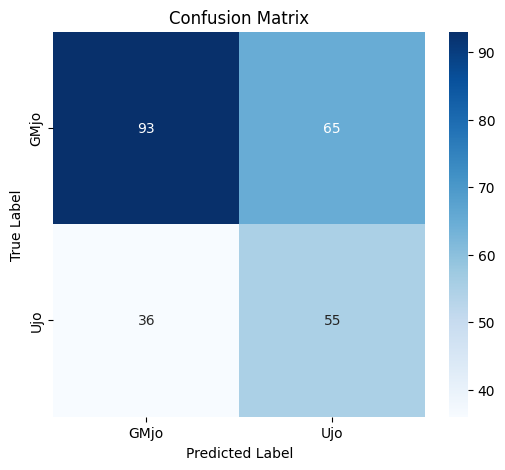

In [ ]:
input_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/5th_int_morphed"

label_map = {"GMjo": 0, "Ujo": 1}

song_data = {}

if os.path.exists(input_dir) and os.listdir(input_dir):
    for song_folder in os.listdir(input_dir):
        song_path = os.path.join(input_dir, song_folder)
        if not os.path.isdir(song_path):
            continue

        X_list = []
        y_list = []

        for file in os.listdir(song_path):
            if file.endswith(".npy"):
                file_path = os.path.join(song_path, file)
                X_sample = np.load(file_path)

                if "GMjo" in file:
                    y_label = label_map["GMjo"]
                elif "Ujo" in file:
                    y_label = label_map["Ujo"]
                else:
                    continue

                X_list.append(X_sample.flatten())
                y_list.append(y_label)

        if X_list:
            song_data[song_folder] = (np.array(X_list), np.array(y_list))


if not song_data:
    print("Data does not exist.")
else:
    song_names = list(song_data.keys())
    num_songs = len(song_names)

    loo_accuracies = []
    y_true, y_pred = [], []
    evaluation_results = []

    for i in range(num_songs):
        test_song = song_names[i]
        val_X, val_y = song_data[test_song]

        train_X, train_y = [], []
        for j, song in enumerate(song_names):
            if i != j:
                train_X.append(song_data[song][0])
                train_y.append(song_data[song][1])

        train_X = np.vstack(train_X)
        train_y = np.concatenate(train_y)

        model = SVC(kernel='linear', C=1.0, random_state=42)
        model.fit(train_X, train_y)

        val_pred = model.predict(val_X)
        y_true.extend(val_y)
        y_pred.extend(val_pred)

        accuracy = accuracy_score(val_y, val_pred)
        loo_accuracies.append(accuracy)
        evaluation_results.append([test_song, accuracy, val_pred.tolist(), val_y.tolist()])

    eval_df = pd.DataFrame(evaluation_results, columns=["Test Song", "Accuracy", "Prediction", "Ground Truth"])

    print("\n====== LOO-CV Evaluation Results ======")
    print(eval_df.to_string(index=False))

    average_accuracy = np.mean(loo_accuracies)
    classification_rep = classification_report(y_true, y_pred, target_names=["GMjo", "Ujo"])

    print("\n====== Overall Evaluation ======")
    print(f"Average Validation Accuracy: {average_accuracy:.4f}")
    print("\nClassification Report:\n", classification_rep)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["GMjo", "Ujo"], yticklabels=["GMjo", "Ujo"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Masked Filter Histogram


====== LOO Cross-Validation Results ======
       Test Song  Accuracy                                                                                                                                                                                       Prediction                                                                                                                                                                                     Ground Truth
  적벽가_군사설움타령_계면조  0.947368                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
     수궁가_소지노화_우조  0.277778                                                                                                        

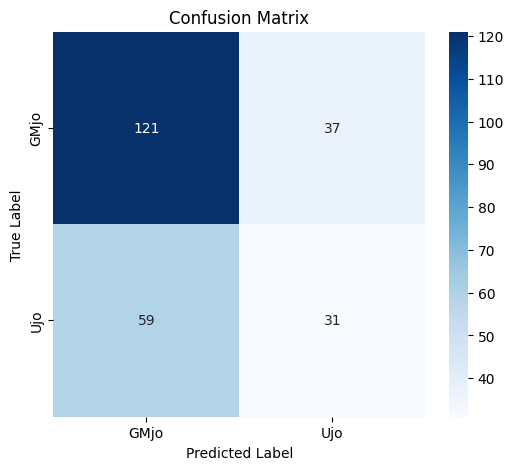

In [10]:
input_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/5th_int_masked"

label_map = {"GMjo": 0, "Ujo": 1}

song_data = {}

for song_folder in os.listdir(input_dir):
    song_path = os.path.join(input_dir, song_folder)
    if not os.path.isdir(song_path):
        continue

    X_list = []
    y_list = []

    for file in os.listdir(song_path):
        if file.endswith(".npy"):
            file_path = os.path.join(song_path, file)
            X_sample = np.load(file_path)

            if "GMjo" in file:
                y_label = label_map["GMjo"]
            elif "Ujo" in file:
                y_label = label_map["Ujo"]
            else:
                continue

            X_list.append(X_sample.flatten())
            y_list.append(y_label)

    if X_list:
        song_data[song_folder] = (np.array(X_list), np.array(y_list))

song_names = list(song_data.keys())
num_songs = len(song_names)

loo_accuracies = []
y_true, y_pred = [], []
evaluation_results = []

for i in range(num_songs):
    test_song = song_names[i]
    val_X, val_y = song_data[test_song]

    train_X, train_y = [], []
    for j, song in enumerate(song_names):
        if i != j:
            train_X.append(song_data[song][0])
            train_y.append(song_data[song][1])

    train_X = np.vstack(train_X)
    train_y = np.concatenate(train_y)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(train_X, train_y)

    val_pred = model.predict(val_X)
    y_true.extend(val_y)
    y_pred.extend(val_pred)

    accuracy = accuracy_score(val_y, val_pred)
    loo_accuracies.append(accuracy)

    evaluation_results.append([test_song, accuracy, val_pred.tolist(), val_y.tolist()])

eval_df = pd.DataFrame(evaluation_results, columns=["Test Song", "Accuracy", "Prediction", "Ground Truth"])

print("\n====== LOO Cross-Validation Results ======")
print(eval_df.to_string(index=False))

print("\n====== Overall Evaluation ======")
print(f"Average Validation Accuracy: {np.mean(loo_accuracies):.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["GMjo", "Ujo"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["GMjo", "Ujo"], yticklabels=["GMjo", "Ujo"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


====== LOO-CV Evaluation Results ======
       Test Song  Accuracy                                                                                                                                                                                       Prediction                                                                                                                                                                                     Ground Truth
  적벽가_군사설움타령_계면조  0.842105                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]                                                                                                                                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
     수궁가_소지노화_우조  0.500000                                                                                                           

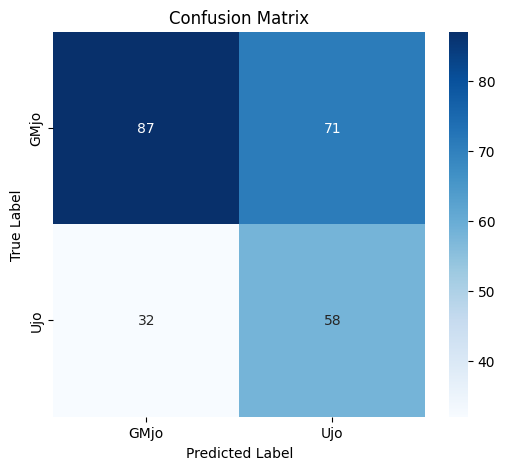

In [ ]:
input_dir = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/5th_int_masked"

label_map = {"GMjo": 0, "Ujo": 1}

song_data = {}

if os.path.exists(input_dir) and os.listdir(input_dir):
    for song_folder in os.listdir(input_dir):
        song_path = os.path.join(input_dir, song_folder)
        if not os.path.isdir(song_path):
            continue

        X_list = []
        y_list = []

        for file in os.listdir(song_path):
            if file.endswith(".npy"):
                file_path = os.path.join(song_path, file)
                X_sample = np.load(file_path)

                if "GMjo" in file:
                    y_label = label_map["GMjo"]
                elif "Ujo" in file:
                    y_label = label_map["Ujo"]
                else:
                    continue

                X_list.append(X_sample.flatten())
                y_list.append(y_label)

        if X_list:
            song_data[song_folder] = (np.array(X_list), np.array(y_list))

if not song_data:
    print("Data does not exist.")
else:
    song_names = list(song_data.keys())
    num_songs = len(song_names)

    loo_accuracies = []
    y_true, y_pred = [], []
    evaluation_results = []

    for i in range(num_songs):
        test_song = song_names[i]
        val_X, val_y = song_data[test_song]

        train_X, train_y = [], []
        for j, song in enumerate(song_names):
            if i != j:
                train_X.append(song_data[song][0])
                train_y.append(song_data[song][1])

        train_X = np.vstack(train_X)
        train_y = np.concatenate(train_y)

        model = SVC(kernel='linear', C=1.0, random_state=42)
        model.fit(train_X, train_y)

        val_pred = model.predict(val_X)
        y_true.extend(val_y)
        y_pred.extend(val_pred)

        accuracy = accuracy_score(val_y, val_pred)
        loo_accuracies.append(accuracy)

        evaluation_results.append([test_song, accuracy, val_pred.tolist(), val_y.tolist()])

    eval_df = pd.DataFrame(evaluation_results, columns=["Test Song", "Accuracy", "Prediction", "Ground Truth"])

    print("\n====== LOO-CV Evaluation Results ======")
    print(eval_df.to_string(index=False))

    average_accuracy = np.mean(loo_accuracies)
    classification_rep = classification_report(y_true, y_pred, target_names=["GMjo", "Ujo"])

    print("\n====== Overall Evaluation ======")
    print(f"Average Validation Accuracy: {average_accuracy:.4f}")
    print("\nClassification Report:\n", classification_rep)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["GMjo", "Ujo"], yticklabels=["GMjo", "Ujo"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()